# 加载数据

In [19]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rc("font",family='YouYuan')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常
plt.rcParams['figure.dpi'] = 100  # 图表基础分辨率
plt.rcParams['savefig.dpi'] = 300  # 保存高清图片
# 加载数据
df = pd.read_csv("奶茶店每日订单.csv")
df

,日期,星期,商品,天气,是否周末,是否促销,销量,客单价,销售额
0,2024-05-21,周二,芋泥波波,雨,False,False,12,11,132
1,2024-05-09,周四,芋泥波波,晴,False,True,39,18,702
2,2024-05-11,周六,柠檬茶,雪,True,False,52,19,988
3,2024-03-01,周五,杨枝甘露,雨,False,False,26,20,520
4,2024-04-18,周四,芋泥波波,雨,False,False,21,17,357
...,...,...,...,...,...,...,...,...,...
2995,2024-05-16,周四,杨枝甘露,雨,False,True,36,18,648
2996,2024-05-09,周四,珍珠奶茶,阴,False,True,32,13,416
2997,2024-04-23,周二,可可奶茶,雨,False,False,23,15,345
2998,2024-03-04,周一,珍珠奶茶,多云,False,False,34,14,476


# 数据清洗

## 空值 

In [20]:

# 检查缺失值
df.isnull().sum()

日期      0
星期      0
商品      0
天气      0
是否周末    0
是否促销    0
销量      0
客单价     0
销售额     0
dtype: int64

In [21]:
## 重复值
df = df.drop_duplicates()
df

,日期,星期,商品,天气,是否周末,是否促销,销量,客单价,销售额
0,2024-05-21,周二,芋泥波波,雨,False,False,12,11,132
1,2024-05-09,周四,芋泥波波,晴,False,True,39,18,702
2,2024-05-11,周六,柠檬茶,雪,True,False,52,19,988
3,2024-03-01,周五,杨枝甘露,雨,False,False,26,20,520
4,2024-04-18,周四,芋泥波波,雨,False,False,21,17,357
...,...,...,...,...,...,...,...,...,...
2995,2024-05-16,周四,杨枝甘露,雨,False,True,36,18,648
2996,2024-05-09,周四,珍珠奶茶,阴,False,True,32,13,416
2997,2024-04-23,周二,可可奶茶,雨,False,False,23,15,345
2998,2024-03-04,周一,珍珠奶茶,多云,False,False,34,14,476


## 异常值

In [22]:
# 销量为什么会有负数，是因为损失吗
df.describe([.25,.50,.75,.99])

,销量,客单价,销售额
count,2996.000000,2996.000000,2996.000000
mean,42.425567,15.472964,477.597463
std,110.638669,3.311477,209.932272
min,-1.000000,10.000000,110.000000
25%,21.000000,13.000000,320.000000
50%,29.000000,15.000000,440.000000
75%,39.000000,18.000000,600.000000
99%,999.000000,22.000000,1080.000000
max,999.000000,22.000000,1430.000000


In [23]:
# 是不是那一天这个商品一件都没卖出去，然后给别人或者自己人吃了
df[df['销量']<0]

,日期,星期,商品,天气,是否周末,是否促销,销量,客单价,销售额
85,2024-04-03,周三,芝士奶盖,雪,False,False,-1,18,396
124,2024-03-12,周二,水果茶,晴,False,False,-1,10,170
139,2024-03-29,周五,芋泥波波,雨,False,False,-1,12,300
146,2024-05-10,周五,柠檬茶,多云,False,False,-1,19,342
207,2024-05-27,周一,抹茶拿铁,多云,False,False,-1,17,442
215,2024-05-26,周日,杨枝甘露,多云,True,False,-1,21,735
382,2024-05-12,周日,水果茶,雪,True,False,-1,11,473
409,2024-04-27,周六,可可奶茶,多云,True,True,-1,11,605
458,2024-05-07,周二,冰美式,多云,False,True,-1,13,299
504,2024-04-01,周一,抹茶拿铁,阴,False,True,-1,10,480


# 分析

## 各商品市场份额占比（销量占比）及可视化

In [24]:
# 1. 计算各商品在不同星期的市场份额 
# 统计“星期-商品”的订单数
day_goods_count = pd.crosstab(df['星期'], df['商品'])
# 计算各城市内，每个品牌的市场份额
day_goods_share = day_goods_count.div(day_goods_count.sum(axis=1), axis=0) * 100 # 转换为成百分比

print("各商品在不同星期的市场份额（%）：")
print(day_goods_share.round(2))

各商品在不同星期的市场份额（%）：
商品    冰美式   可可奶茶   抹茶拿铁   杨枝甘露    柠檬茶    水果茶   珍珠奶茶   芋泥波波   芝士奶盖   青稞奶茶
星期                                                                      
周一   9.11   9.35  12.47  10.31   8.39   9.83   9.59   9.59  11.27  10.07
周三  10.02   8.91   9.80  11.14   9.80  12.25   8.24   9.35  11.36   9.13
周二   8.85   8.61  11.24   9.57  11.48  11.00   7.42  10.53  10.05  11.24
周五  11.16   9.15  10.04  12.72  10.71  10.71   7.14   9.82   9.60   8.93
周六   6.70  10.71   9.82  11.61  10.49   9.15  10.49   8.48  10.71  11.83
周四   9.27  12.68  10.00  10.49   8.05  10.24  10.24   8.78  10.49   9.76
周日   9.61   9.36  13.05  11.82   9.11   7.88  10.59  11.08   9.61   7.88


In [25]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7),dpi=1000)

# 子图1：市场份额热力图（直观展示城市-品牌的份额分布）
sns.heatmap(
    day_goods_share,
    annot=True,  # 显示数值
    fmt=".1f",  # 数值保留1位小数
    cmap="YlGnBu",  # 配色（浅绿到深蓝）
    ax=ax1,
    cbar_kws={"label": "市场份额（%）"}
)
ax1.set_title("各品牌在不同城市的市场份额热力图", fontsize=14, fontweight="bold")
ax1.set_xlabel("品牌", fontsize=12)
ax1.set_ylabel("城市等级", fontsize=12)

Text(1965.9409722222222, 0.5, '城市等级')

In [26]:

print("\n核心结论")
# 找出每个星期卖的最好的品
day_top1_goods = day_goods_share.idxmax(axis=1)
# 找出每个品的优势星期
goods_advantage_day = day_goods_share.idxmax(axis=0)

for day in day_top1_goods.index:
    top_goods = day_top1_goods[day]
    top_share = day_goods_share.loc[day, top_goods].round(2)
    print(f"- {day}星期卖的最好的品是【{top_goods}】，市场份额{top_share}%")

for goods in goods_advantage_day.index:
    adv_day = goods_advantage_day[goods]
    adv_share = day_goods_share.loc[adv_day, goods].round(2)
    print(f"- 【{goods}】的优势星期是{adv_day}，在该星期份额{adv_share}%")



核心结论
- 周一星期卖的最好的品是【抹茶拿铁】，市场份额12.47%
- 周三星期卖的最好的品是【水果茶】，市场份额12.25%
- 周二星期卖的最好的品是【柠檬茶】，市场份额11.48%
- 周五星期卖的最好的品是【杨枝甘露】，市场份额12.72%
- 周六星期卖的最好的品是【青稞奶茶】，市场份额11.83%
- 周四星期卖的最好的品是【可可奶茶】，市场份额12.68%
- 周日星期卖的最好的品是【抹茶拿铁】，市场份额13.05%
- 【冰美式】的优势星期是周五，在该星期份额11.16%
- 【可可奶茶】的优势星期是周四，在该星期份额12.68%
- 【抹茶拿铁】的优势星期是周日，在该星期份额13.05%
- 【杨枝甘露】的优势星期是周五，在该星期份额12.72%
- 【柠檬茶】的优势星期是周二，在该星期份额11.48%
- 【水果茶】的优势星期是周三，在该星期份额12.25%
- 【珍珠奶茶】的优势星期是周日，在该星期份额10.59%
- 【芋泥波波】的优势星期是周日，在该星期份额11.08%
- 【芝士奶盖】的优势星期是周三，在该星期份额11.36%
- 【青稞奶茶】的优势星期是周六，在该星期份额11.83%


## 偏好分析
核心问题：奶茶消费者的天气、周末偏好有哪些规律？促销与不促销的偏好是否存在差异？

分析子问题与代码：

天气、周末偏好分布

促销与偏好的关联性分析

不同季节（月份）的销售额偏好变化

In [27]:
df.head()

,日期,星期,商品,天气,是否周末,是否促销,销量,客单价,销售额
0,2024-05-21,周二,芋泥波波,雨,False,False,12,11,132
1,2024-05-09,周四,芋泥波波,晴,False,True,39,18,702
2,2024-05-11,周六,柠檬茶,雪,True,False,52,19,988
3,2024-03-01,周五,杨枝甘露,雨,False,False,26,20,520
4,2024-04-18,周四,芋泥波波,雨,False,False,21,17,357


### 天气、周末偏好分布

In [28]:

season_map = {1:'冬',2:'冬',3:'春',4:'春',5:'春',6:'夏',7:'夏',8:'夏',9:'秋',10:'秋',11:'秋',12:'冬'}
df['日期']=pd.to_datetime(df['日期'])
df['month']=df['日期'].dt.month
df['season'] = df['month'].map(season_map)
df


C:\Users\35796\AppData\Local\Temp\ipykernel_42736\2943124039.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['日期']=pd.to_datetime(df['日期'])
C:\Users\35796\AppData\Local\Temp\ipykernel_42736\2943124039.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month']=df['日期'].dt.month
C:\Users\35796\AppData\Local\Temp\ipykernel_42736\2943124039.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

,日期,星期,商品,天气,是否周末,是否促销,销量,客单价,销售额,month,season
0,2024-05-21,周二,芋泥波波,雨,False,False,12,11,132,5,春
1,2024-05-09,周四,芋泥波波,晴,False,True,39,18,702,5,春
2,2024-05-11,周六,柠檬茶,雪,True,False,52,19,988,5,春
3,2024-03-01,周五,杨枝甘露,雨,False,False,26,20,520,3,春
4,2024-04-18,周四,芋泥波波,雨,False,False,21,17,357,4,春
...,...,...,...,...,...,...,...,...,...,...,...
2995,2024-05-16,周四,杨枝甘露,雨,False,True,36,18,648,5,春
2996,2024-05-09,周四,珍珠奶茶,阴,False,True,32,13,416,5,春
2997,2024-04-23,周二,可可奶茶,雨,False,False,23,15,345,4,春
2998,2024-03-04,周一,珍珠奶茶,多云,False,False,34,14,476,3,春


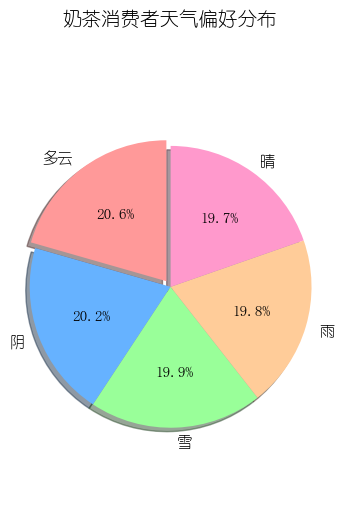

In [29]:
# 绘制天气偏好饼图
sugar_counts = df['天气'].value_counts()
fig1, ax1 = plt.subplots(figsize=(4, 6))
explode = [0.05 if i==0 else 0 for i in range(len(sugar_counts))]
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
ax1.pie(sugar_counts.values, labels=sugar_counts.index, autopct='%1.1f%%',
        explode=explode, colors=colors, shadow=True, startangle=90,
        textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title('奶茶消费者天气偏好分布', fontsize=14, fontweight='bold', pad=20)
ax1.axis('equal')
plt.show()
plt.savefig('天气偏好饼图.png', bbox_inches='tight', facecolor='white')
plt.close()

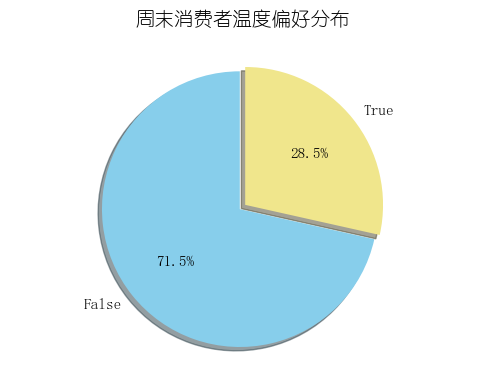

In [30]:
# 1.2 温度偏好饼图
temp_counts = df['是否周末'].value_counts()
fig2, ax2 = plt.subplots(figsize=(6, 4))
explode = [0.05 if i==0 else 0 for i in range(len(temp_counts))]
colors = ['#87CEEB', '#F0E68C', '#FF6347', '#DEB887', '#D3D3D3']
ax2.pie(temp_counts.values, labels=temp_counts.index, autopct='%1.1f%%',
        explode=explode, colors=colors, shadow=True, startangle=90,
        textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('周末消费者温度偏好分布', fontsize=14, fontweight='bold', pad=20)
ax2.axis('equal')
plt.show()
plt.savefig('周末偏好饼图.png', bbox_inches='tight', facecolor='white')
plt.close()

In [31]:
df.head()
pd.crosstab(df['商品'], df['month'], normalize='index') * 100


month,3,4,5
商品,,,
冰美式,29.963899,31.768953,38.267148
可可奶茶,32.653061,31.632653,35.714286
抹茶拿铁,35.889571,29.447853,34.662577
杨枝甘露,30.930931,32.132132,36.936937
柠檬茶,38.356164,31.849315,29.794521
水果茶,28.524590,35.081967,36.393443
珍珠奶茶,35.661765,27.941176,36.397059
芋泥波波,30.795848,31.833910,37.370242
芝士奶盖,33.546326,36.421725,30.031949


In [32]:
df.head()


,日期,星期,商品,天气,是否周末,是否促销,销量,客单价,销售额,month,season
0,2024-05-21,周二,芋泥波波,雨,False,False,12,11,132,5,春
1,2024-05-09,周四,芋泥波波,晴,False,True,39,18,702,5,春
2,2024-05-11,周六,柠檬茶,雪,True,False,52,19,988,5,春
3,2024-03-01,周五,杨枝甘露,雨,False,False,26,20,520,3,春
4,2024-04-18,周四,芋泥波波,雨,False,False,21,17,357,4,春


===== 分析1：天气&周末销量分析结果 =====


C:\Users\35796\AppData\Local\Temp\ipykernel_42736\922181534.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='天气', y='销量', data=weather_sales, palette='viridis', edgecolor='black')


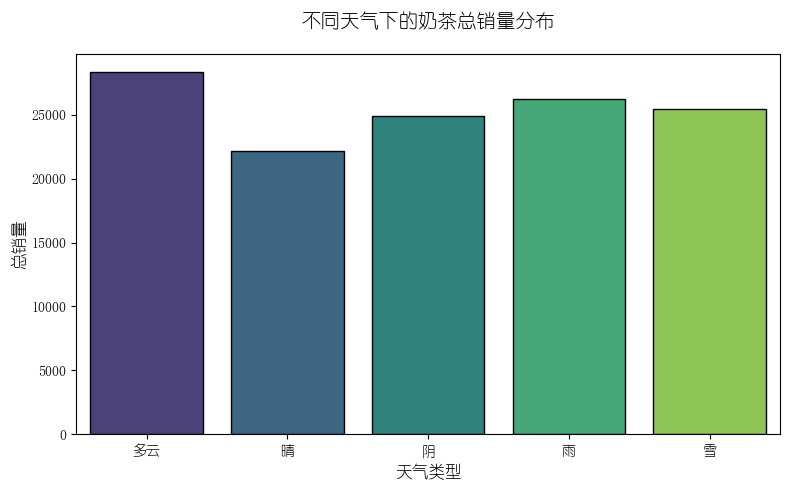

C:\Users\35796\AppData\Local\Temp\ipykernel_42736\922181534.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='是否周末', y='销量', data=weekend_sales, palette='coolwarm', edgecolor='black')


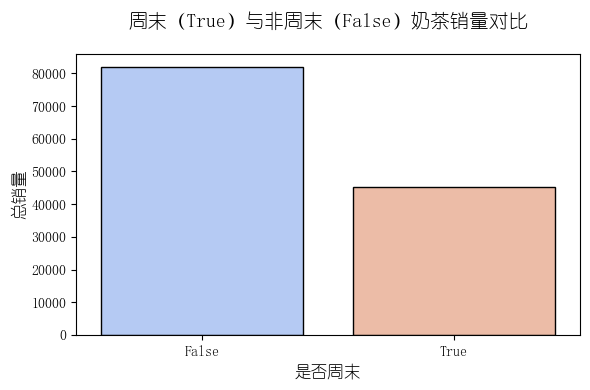

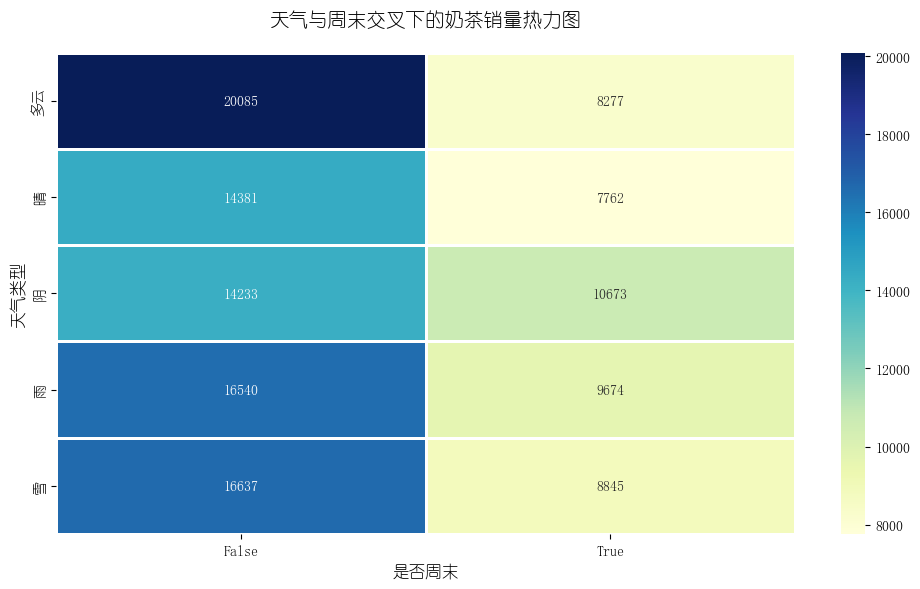

天气+周末交叉销量：
是否周末  False  True 
天气                
多云    20085   8277
晴     14381   7762
阴     14233  10673
雨     16540   9674
雪     16637   8845

===== 分析2：促销与商品偏好关联性分析结果 =====


<Figure size 1200x600 with 0 Axes>

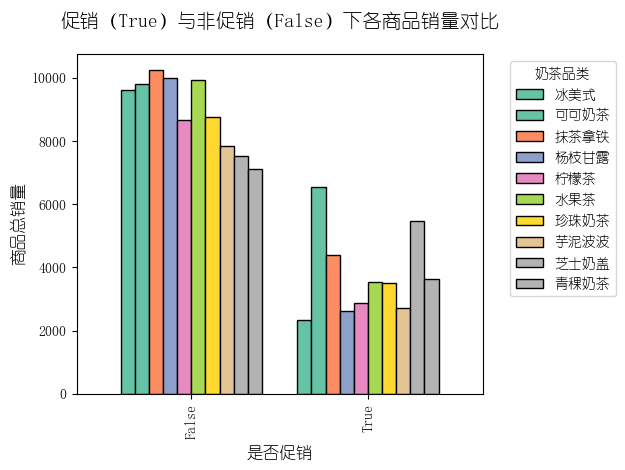

促销与非促销整体销量/销售额对比：
    是否促销     销量      销售额
0  False  89482  1006129
1   True  37625   424753

卡方统计量：4.41 | 自由度：9 | P值：0.8824
结论：促销与商品选择无【显著关联性】（P≥0.05），促销未改变消费者的商品偏好

===== 分析3：季节&月度销售额分析结果 =====


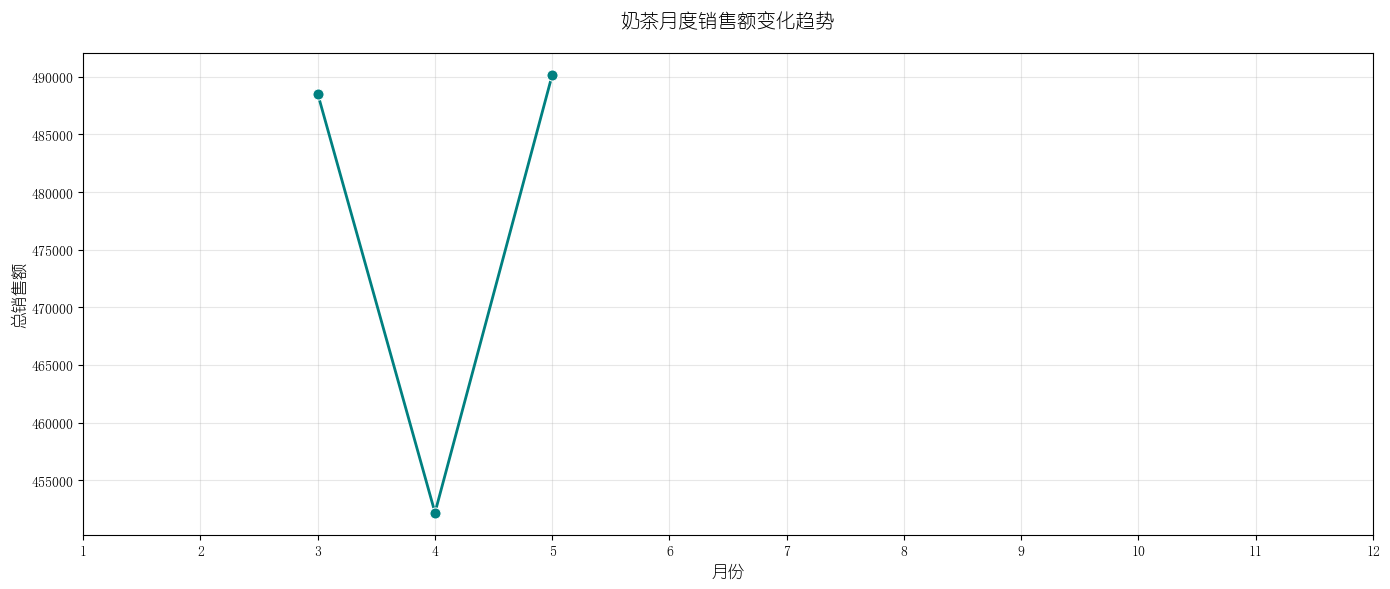

C:\Users\35796\AppData\Local\Temp\ipykernel_42736\922181534.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='销售额', data=season_sales, palette='pastel', edgecolor='black')
C:\Users\35796\AppData\Local\Temp\ipykernel_42736\922181534.py:85: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.barplot(x='season', y='销售额', data=season_sales, palette='pastel', edgecolor='black')


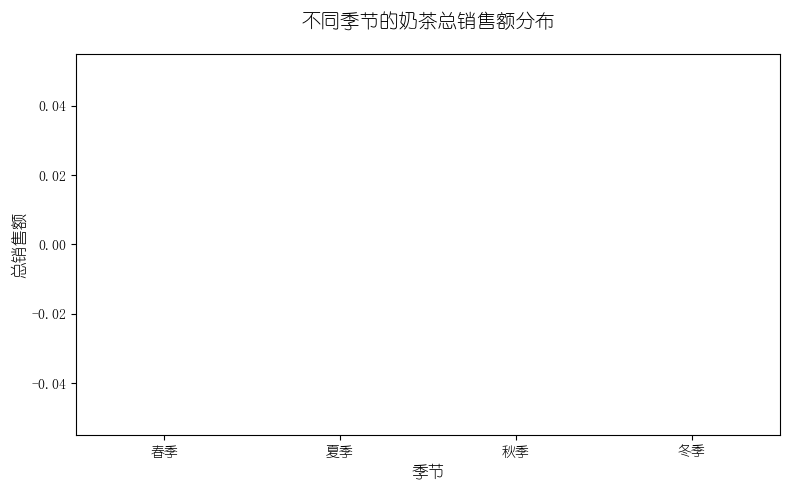

<Figure size 1400x700 with 0 Axes>

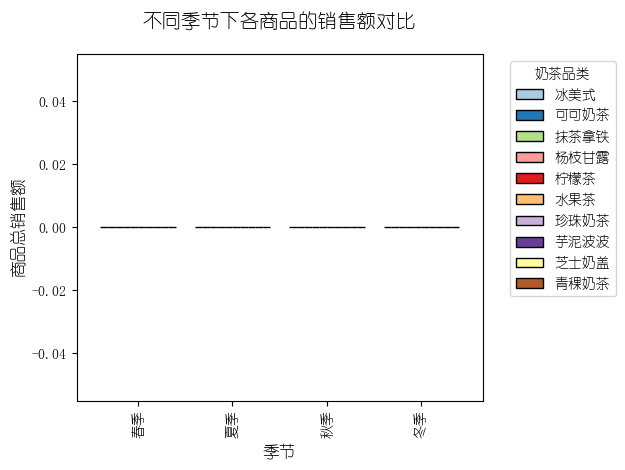

各季节总销售额：
  season      销售额
0    NaN  1430882

===== 所有分析完成！=====


: 

In [ ]:
# 导入所需库（包含chi2_contingency的导入，核心修复行）
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency  # 这行是关键，之前漏了/没执行这行
print("===== 分析1：天气&周末销量分析结果 =====")
# 1.1 不同天气的总销量
weather_sales = df.groupby('天气')['销量'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='天气', y='销量', data=weather_sales, palette='viridis', edgecolor='black')
plt.title('不同天气下的奶茶总销量分布', fontsize=14, pad=20)
plt.xlabel('天气类型', fontsize=12)
plt.ylabel('总销量', fontsize=12)
plt.tight_layout()
plt.show()

# 1.2 周末/非周末的销量对比
weekend_sales = df.groupby('是否周末')['销量'].sum().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(x='是否周末', y='销量', data=weekend_sales, palette='coolwarm', edgecolor='black')
plt.title('周末（True）与非周末（False）奶茶销量对比', fontsize=14, pad=20)
plt.xlabel('是否周末', fontsize=12)
plt.ylabel('总销量', fontsize=12)
plt.tight_layout()
plt.show()

# 1.3 天气+周末的交叉销量热力图（带数值标注）
weather_weekend_sales = df.groupby(['天气', '是否周末'])['销量'].sum().unstack()
plt.figure(figsize=(10, 6))
sns.heatmap(weather_weekend_sales, annot=True, cmap='YlGnBu', fmt='d', linewidths=1)
plt.title('天气与周末交叉下的奶茶销量热力图', fontsize=14, pad=20)
plt.xlabel('是否周末', fontsize=12)
plt.ylabel('天气类型', fontsize=12)
plt.tight_layout()
plt.show()
print(f"天气+周末交叉销量：\n{weather_weekend_sales}\n")

# -------------------------- 分析2：促销与偏好的关联性分析 --------------------------
print("===== 分析2：促销与商品偏好关联性分析结果 =====")
# 2.1 促销/非促销下各商品的销量对比（柱状图）
promo_product_sales = df.groupby(['是否促销', '商品'])['销量'].sum().unstack()
plt.figure(figsize=(12, 6))
promo_product_sales.plot(kind='bar', colormap='Set2', edgecolor='black', width=0.8)
plt.title('促销（True）与非促销（False）下各商品销量对比', fontsize=14, pad=20)
plt.xlabel('是否促销', fontsize=12)
plt.ylabel('商品总销量', fontsize=12)
plt.legend(title='奶茶品类', bbox_to_anchor=(1.05, 1), loc='upper left')  # 图例右移，避免遮挡
plt.tight_layout()
plt.show()

# 2.2 促销对整体销量/销售额的拉动效果
promo_total = df.groupby('是否促销')[['销量', '销售额']].sum().reset_index()
print(f"促销与非促销整体销量/销售额对比：\n{promo_total}\n")

# 2.3 卡方检验：验证「促销」与「商品选择」是否存在显著关联（核心统计检验）
contingency_table = pd.crosstab(df['是否促销'], df['商品'])  # 构建列联表
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"卡方统计量：{chi2:.2f} | 自由度：{dof} | P值：{p:.4f}")
if p < 0.05:
    print("结论：促销与商品选择存在【显著关联性】（P<0.05），促销改变了消费者的商品偏好\n")
else:
    print("结论：促销与商品选择无【显著关联性】（P≥0.05），促销未改变消费者的商品偏好\n")

# -------------------------- 分析3：不同季节（月份）的销售额偏好变化分析 --------------------------
print("===== 分析3：季节&月度销售额分析结果 =====")
# 3.1 月度销售额变化趋势（折线图，带标记点）
monthly_sales = df.groupby('month')['销售额'].sum().reset_index()
plt.figure(figsize=(14, 6))
sns.lineplot(x='month', y='销售额', data=monthly_sales, marker='o', linewidth=2, markersize=8, color='teal')
plt.title('奶茶月度销售额变化趋势', fontsize=14, pad=20)
plt.xlabel('月份', fontsize=12)
plt.ylabel('总销售额', fontsize=12)
plt.xticks(range(1, 13))  # 强制显示1-12月
plt.grid(alpha=0.3)  # 网格透明化
plt.tight_layout()
plt.show()

# 3.2 不同季节的销售额分布
season_sales = df.groupby('season')['销售额'].sum().reset_index()
# 按四季顺序排序（避免绘图乱序）
season_sales['season'] = pd.Categorical(season_sales['season'], categories=['春季','夏季','秋季','冬季'], ordered=True)
season_sales = season_sales.sort_values('season')

plt.figure(figsize=(8, 5))
sns.barplot(x='season', y='销售额', data=season_sales, palette='pastel', edgecolor='black')
plt.title('不同季节的奶茶总销售额分布', fontsize=14, pad=20)
plt.xlabel('季节', fontsize=12)
plt.ylabel('总销售额', fontsize=12)
plt.tight_layout()
plt.show()

# 3.3 季节与商品的销售额交叉对比（柱状图）
season_product_sales = df.groupby(['season', '商品'])['销售额'].sum().unstack()
# 按四季顺序排序
season_product_sales = season_product_sales.reindex(['春季','夏季','秋季','冬季'])
plt.figure(figsize=(14, 7))
season_product_sales.plot(kind='bar', colormap='Paired', edgecolor='black', width=0.8)
plt.title('不同季节下各商品的销售额对比', fontsize=14, pad=20)
plt.xlabel('季节', fontsize=12)
plt.ylabel('商品总销售额', fontsize=12)
plt.legend(title='奶茶品类', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print(f"各季节总销售额：\n{season_sales}\n")

print("===== 所有分析完成！=====")